In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("results")

L        = 20
N        = 13
g        = 2
chi_list = [64, 128]

In [2]:
data = {}
for chi in chi_list:
    d = np.load(RESULTS_DIR / f"ni_L{L}_N{N}_chi{chi}_g{g}.npz")
    data[chi] = {
        "ni"    : d["ni"],
        "tr_TB" : d["tr_TB"],
        "t_grid": d["t_grid"],
        "W"     : float(d["W"]),
    }

t_grid = data[chi_list[0]]["t_grid"]
W      = data[chi_list[0]]["W"]

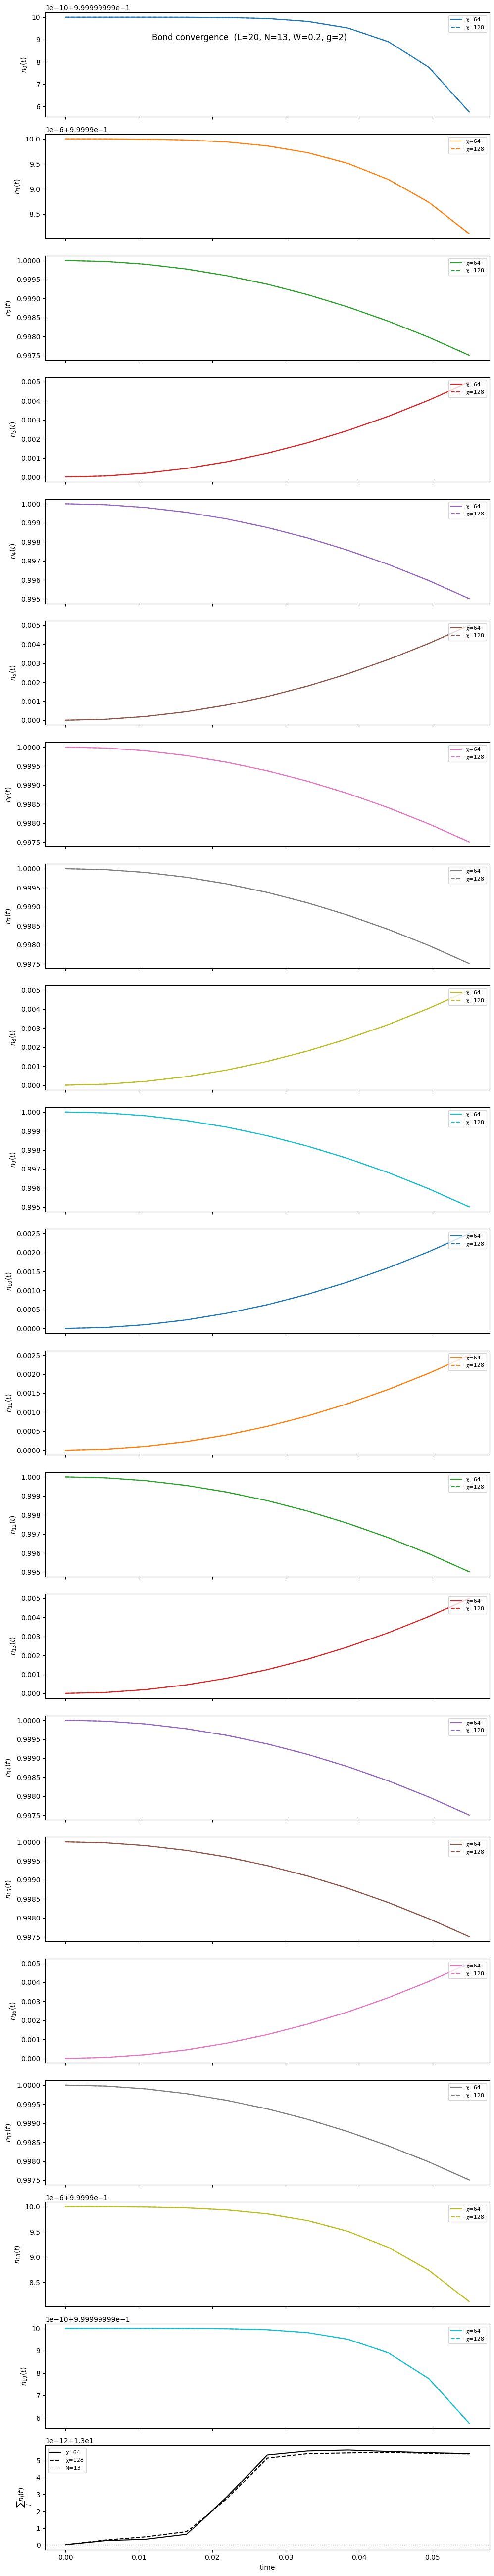

In [3]:
linestyles = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(L + 1, 1, figsize=(10, 2.5 * (L + 1)), sharex=True)

for j in range(L):
    for k, chi in enumerate(chi_list):
        axes[j].plot(
            t_grid, data[chi]["ni"][j, :],
            linestyle=linestyles[k], color=f"C{j}",
            label=f"χ={chi}",
        )
    axes[j].set_ylabel(f"$n_{{{j}}}(t)$")
    axes[j].legend(loc="upper right", fontsize=8)

for k, chi in enumerate(chi_list):
    axes[L].plot(
        t_grid, np.sum(data[chi]["ni"], axis=0),
        linestyle=linestyles[k], color="k",
        label=f"χ={chi}",
    )
axes[L].axhline(N, color="gray", linestyle=":", linewidth=1, label=f"N={N}")
axes[L].set_ylabel(r"$\sum_j n_j(t)$")
axes[L].set_xlabel("time")
axes[L].legend(loc="upper left", fontsize=8)

plt.suptitle(f"Bond convergence  (L={L}, N={N}, W={W}, g={g})", fontsize=12)
plt.tight_layout()
plt.show()